<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Ademola_EKF_UKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [180]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd

import copy

In [181]:

try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

In [182]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

$$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) = \mathbf{f_0}(\mathbf{x}) + \mathbf{f_1}(\mathbf{x})\bbox[lightgreen]{\alpha} + \mathbf{f_2}(\mathbf{x})\bbox[lightgreen]{\kappa}
$$

$$
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{V} \\[0.3em]
\bbox[yellow]{I} \\[0.3em]
\bbox[yellow]{R} \\[0.3em]
\bbox[pink]{\beta} \\[0.3em]
\bbox[pink]{\sigma}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[lightblue]{\Lambda} - \bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[lightblue]{\mu}\bbox[yellow]{S} \\[0.3em]
0 - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\mu}\bbox[yellow]{V} \\[0.3em]
\bbox[pink]{\beta}\bbox[yellow]{SI} + \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} - \bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{I} \\[0.3em]
\bbox[lightblue]{\gamma}\bbox[yellow]{I} - \bbox[lightblue]{\mu}\bbox[yellow]{R}\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
-\bbox[yellow]{S} \\[0.3em]
\bbox[yellow]{S} \\[0.3em]
0 \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\alpha} +
\overset{f_2}{\begin{bmatrix}
\bbox[pink]{\beta}\bbox[yellow]{SI} \\[0.3em]
\bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
-\bbox[pink]{\beta}\bbox[yellow]{SI} - \bbox[pink]{\sigma}\bbox[pink]{\beta}\bbox[yellow]{VI} \\[0.3em]
0\\[0.3em]
0\\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{\kappa}
$$

# Dynamics and measurement functions

In [183]:
# all three measurement functions can be accessed from the planar drone script:
h_a = tb_simulations.H('h_ivr').h
h_b = tb_simulations.H('h_all_svir').h


In [184]:
f = tb_simulations.F().f
h = h_b # choose one of the measurement functions

In [185]:
h(None, None, return_measurement_names=True)

['S_absolute', 'V_absolute', 'I_absolute', 'R_absolute']

# Run MPC simulation

In [186]:

t_sim, x_sim, u_sim, y_sim, simulator = tb_simulations.simulate_tb(
    f,
    h,
    tsim_length=365,
    dt=1.0
)

In [187]:
y_sim_corrected = {
    'I_absolute': x_sim['I'],
    'V_absolute': x_sim['V'],
    'R_absolute': x_sim['R']
}

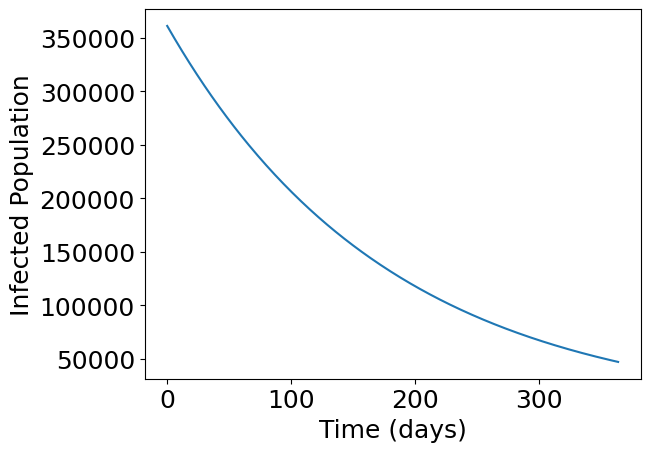

In [188]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t_sim, x_sim['I'])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Infected Population')
plt.show()

# Simulate noisy measurements

In [189]:
# Measurement noise
measurement_noise_stds = {
    'S_absolute': 5000.0,
    'I_absolute': 5000.0,
    'V_absolute': 10000.0,
    'R_absolute': 5000.0
}

In [190]:
y_noisy = {key: y_sim_corrected[key] + np.random.normal(0, measurement_noise_stds[key], len(y_sim_corrected[key]))
           for key in y_sim_corrected.keys()}

<Axes: xlabel='Time', ylabel='V_absolute'>

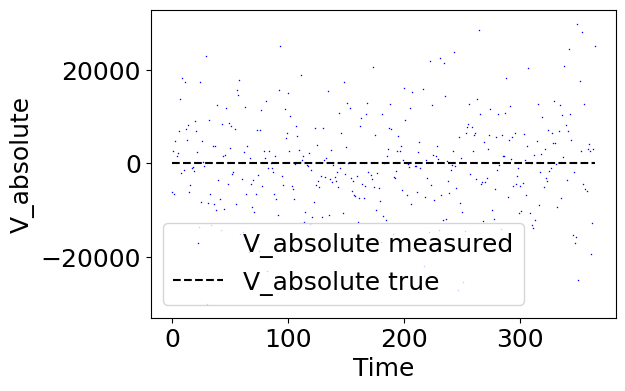

In [191]:
plot_tme(t_sim, y_sim['V_absolute'], y_noisy['V_absolute'], label_var='V_absolute')

<Axes: xlabel='Time', ylabel='I_absolute'>

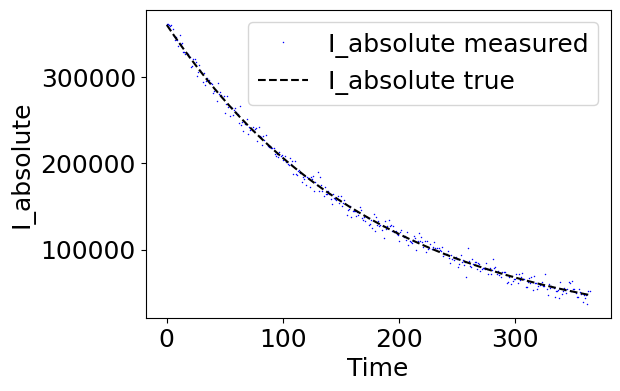

In [192]:
plot_tme(t_sim, y_sim['I_absolute'], y_noisy['I_absolute'], label_var='I_absolute')

<Axes: xlabel='Time', ylabel='R_absolute'>

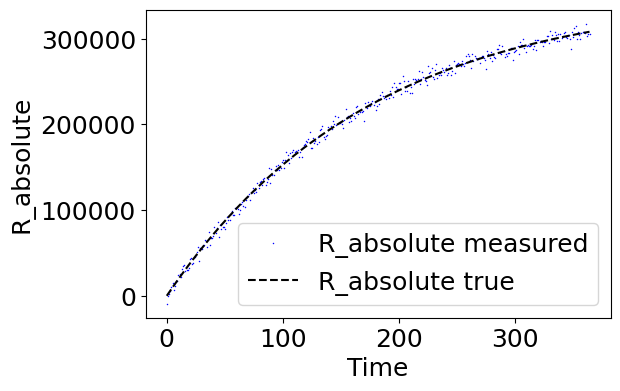

In [193]:
plot_tme(t_sim, y_sim['R_absolute'], y_noisy['R_absolute'], label_var='R_absolute')

### Save data as dataframes

In [194]:
y_noisy_df = pd.DataFrame(y_noisy)
u_sim_df = pd.DataFrame(u_sim)
x_sim_df = pd.DataFrame(x_sim)

# Kalman filter parameters and initilization

In [195]:
x0 = np.array([x_sim['S'][0], x_sim['V'][0], x_sim['I'][0],
               x_sim['R'][0], x_sim['beta'][0], x_sim['sigma'][0]])
u0 = np.array([u_sim['alpha'][0], u_sim['kappa'][0]])

In [196]:
P0 = np.diag([
    1e10,
    1e10,
    1e8,
    1e10,
    0.001,
    0.001
])

In [197]:
Q = np.diag([
    1e6,
    1e6,
    1e4,
    1e6,
    1e-8,
    1e-8
])
R = np.diag(list(measurement_noise_stds.values()))**2

In [198]:
dt = 1.0 #np.mean(np.diff(t_sim))

# Extended Kalman Filter

In [199]:
EKF = extended_kalman_filter.EKF(
    f, h, x0, u0, P0, Q, R,
    dynamics_type='continuous',
    discretization_timestep=dt,
    circular_measurements=(0, 0, 0, 0, 0, 0)
)

In [200]:
EKF.estimate(y_noisy_df, u_sim_df)

In [201]:
EKF.history.keys()

dict_keys(['X', 'U', 'Z', 'P', 'P_diags', 'R', 'Q', 'F', 'H', 'S', 'K', 'E', 'rho', 'Jk', 'inv_Jk'])

In [202]:
# State estimate
x_est = pd.DataFrame(np.vstack(EKF.history['X']), columns=f(None,None,return_state_names=True))

In [203]:
# Covariance diagonals
P_diags = np.vstack([np.diag(EKF.history['P'][i]) for i in range(len(EKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

state = 'V_absolute'

plot_tme(t_sim, x_sim[state], None, x_est[state], label_var=state, ax=ax)

plus3sigma = x_est[state] + 3*np.sqrt(P_diags[state])
minus3sigma = x_est[state] - 3*np.sqrt(P_diags[state])

ax.fill_between(t_sim, plus3sigma, minus3sigma, facecolor='red', edgecolor='none', alpha=0.2)